# Fuzzy Logic: Prediksi Rating Perusahaan

Notebook ini menggunakan Fuzzy Mamdani dan Fuzzy Sugeno untuk memprediksi `Rating` perusahaan berdasarkan lima variabel input numerik.

## 1. Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True

In [2]:
df = pd.read_csv('data.csv')
df.head()

,Unnamed: 0,Name,Rating,Branches,Highly_rated,Critically_rated,Reviews,Salaries,Interviews,Jobs,Benefits,Logo_URL
0,0,TCS,3.8,4.0,"Job Security, Work Life Balance, Company Culture","Promotions / Appraisal, Salary & Benefits",67k,737.1k,5.6k,278,11.3k,https://static.ambitionbox.com/alpha/company/p...
1,1,Accenture,4.1,2.0,"Company Culture, Job Security, Skill Developme...",NaN,42.9k,513.8k,3.9k,4.1k,7k,https://static.ambitionbox.com/assets/v2/image...
2,2,Cognizant,3.9,2.0,Skill Development / Learning,NaN,38.6k,497.3k,3.3k,480,5.8k,https://static.ambitionbox.com/alpha/company/p...
3,3,Wipro,3.8,3.0,Job Security,NaN,35.6k,371.3k,3.3k,340,4.9k,https://static.ambitionbox.com/assets/v2/image...
4,4,ICICI Bank,4.0,2.0,"Job Security, Skill Development / Learning, Co...",NaN,31k,136.4k,1.7k,216,3.7k,https://static.ambitionbox.com/assets/v2/image...


In [3]:
df.shape

(10000, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        10000 non-null  int64  
 1   Name              10000 non-null  object 
 2   Rating            10000 non-null  float64
 3   Branches          2729 non-null   float64
 4   Highly_rated      8029 non-null   object 
 5   Critically_rated  237 non-null    object 
 6   Reviews           10000 non-null  object 
 7   Salaries          10000 non-null  object 
 8   Interviews        10000 non-null  object 
 9   Jobs              10000 non-null  object 
 10  Benefits          10000 non-null  object 
 11  Logo_URL          10000 non-null  object 
dtypes: float64(2), int64(1), object(9)
memory usage: 937.6+ KB


In [5]:
df.isnull().sum()

,0
Unnamed: 0,0
Name,0
Rating,0
Branches,7271
Highly_rated,1971
Critically_rated,9763
Reviews,0
Salaries,0
Interviews,0
Jobs,0


## 2. Pemeriksaan Kolom yang Tidak Digunakan

Kolom `Branches`, `Highly_rated`, dan `Critically_rated` diperiksa untuk membuktikan alasan tidak digunakan pada model utama.

In [6]:
excluded_cols = ['Branches', 'Highly_rated', 'Critically_rated']

excluded_check = pd.DataFrame({
    'missing_count': df[excluded_cols].isnull().sum(),
    'missing_percent': df[excluded_cols].isnull().mean() * 100,
    'dtype': df[excluded_cols].dtypes.astype(str),
    'unique_count': df[excluded_cols].nunique(dropna=True)
})

excluded_check

,missing_count,missing_percent,dtype,unique_count
Branches,7271,72.71,float64,9
Highly_rated,1971,19.71,object,252
Critically_rated,9763,97.63,object,29


`Branches` dan `Critically_rated` tidak digunakan karena missing value besar. `Highly_rated` dan `Critically_rated` juga berbentuk teks kategorikal bebas sehingga membutuhkan encoding tambahan di luar model fuzzy utama.

## 3. Konversi Data Numerik

In [7]:
def convert_k(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    if x in ['--', '-', '', 'nan']:
        return np.nan
    if 'k' in x:
        return float(x.replace('k', '')) * 1000
    return float(x)

In [8]:
input_cols = ['Reviews', 'Salaries', 'Interviews', 'Jobs', 'Benefits']
output_col = 'Rating'

for col in input_cols:
    df[col] = df[col].apply(convert_k)

missing_after_conversion = df[input_cols].isnull().sum()
missing_after_conversion

,0
Reviews,0
Salaries,0
Interviews,279
Jobs,4047
Benefits,51


## 4. Drop Row Missing Value

Baris yang masih memiliki missing value pada variabel model dihapus. Strategi ini dipilih karena jumlah data setelah penghapusan masih lebih dari 5.000 baris dan tidak membuat nilai buatan seperti pada imputasi.

In [9]:
rows_before_drop = len(df)

df_model = df[input_cols + [output_col]].dropna().reset_index(drop=True)

rows_after_drop = len(df_model)
rows_removed = rows_before_drop - rows_after_drop

pd.DataFrame({
    'keterangan': ['sebelum_drop', 'setelah_drop', 'baris_dihapus'],
    'jumlah_baris': [rows_before_drop, rows_after_drop, rows_removed]
})

,keterangan,jumlah_baris
0,sebelum_drop,10000
1,setelah_drop,5867
2,baris_dihapus,4133


In [10]:
df_model.isnull().sum()

,0
Reviews,0
Salaries,0
Interviews,0
Jobs,0
Benefits,0
Rating,0


In [11]:
df_model.describe()

,Reviews,Salaries,Interviews,Jobs,Benefits,Rating
count,5867.000000,5867.000000,5867.000000,5867.000000,5867.000000,5867.000000
mean,517.356571,3180.664735,32.848304,32.282768,73.414863,3.822090
std,1909.768614,18029.463444,159.989042,113.937823,288.245898,0.379076
min,66.000000,5.000000,1.000000,1.000000,1.000000,1.600000
25%,99.000000,565.000000,5.000000,3.000000,12.000000,3.600000
50%,166.000000,959.000000,10.000000,9.000000,23.000000,3.900000
75%,360.000000,2000.000000,22.000000,26.000000,53.000000,4.100000
max,67000.000000,737100.000000,5600.000000,4100.000000,11300.000000,4.900000


In [12]:
X = df_model[input_cols]
y = df_model[output_col]

## 5. Fungsi Keanggotaan

Fungsi yang digunakan adalah linier naik, linier turun, segitiga, dan trapesium.

In [13]:
def linier_naik(x, a, b):
    if x <= a:
        return 0.0
    if x >= b:
        return 1.0
    return (x - a) / (b - a)


def linier_turun(x, a, b):
    if x <= a:
        return 1.0
    if x >= b:
        return 0.0
    return (b - x) / (b - a)


def segitiga(x, a, b, c):
    if x <= a or x >= c:
        return 0.0
    if x == b:
        return 1.0
    if a < x < b:
        return (x - a) / (b - a)
    return (c - x) / (c - b)


def trapesium(x, a, b, c, d):
    if x <= a:
        if a == b and x == a:
            return 1.0
        return 0.0
    if x >= d:
        if c == d and x == d:
            return 1.0
        return 0.0
    if b <= x <= c:
        return 1.0
    if a < x < b:
        return (x - a) / (b - a)
    return (d - x) / (d - c)


def hitung_mf(x, params):
    jenis = params[0]
    if jenis == 'linier_naik':
        return linier_naik(x, params[1], params[2])
    if jenis == 'linier_turun':
        return linier_turun(x, params[1], params[2])
    if jenis == 'segitiga':
        return segitiga(x, params[1], params[2], params[3])
    if jenis == 'trapesium':
        return trapesium(x, params[1], params[2], params[3], params[4])
    raise ValueError('Jenis fungsi keanggotaan tidak dikenal')

## 6. Variabel Linguistik Input

Setiap input memakai lima nilai linguistik: `sangat_rendah`, `rendah`, `sedang`, `tinggi`, dan `sangat_tinggi`.

Batas linguistik tidak memakai nilai maksimum ekstrem sebagai batas utama, karena data memiliki outlier besar. Batas dipilih dari pusat sebaran data agar fungsi keanggotaan tetap representatif terhadap mayoritas data.

In [14]:
batas_linguistik = pd.DataFrame({
    'variabel': ['Reviews', 'Salaries', 'Interviews', 'Jobs', 'Benefits'],
    'a': [76, 395, 3, 1, 7],
    'b': [99, 565, 5, 3, 12],
    'c': [166, 959, 10, 9, 23],
    'd': [360, 2000, 22, 26, 53],
    'e': [970, 5100, 55, 66, 136]
})

batas_linguistik

,variabel,a,b,c,d,e
0,Reviews,76,99,166,360,970
1,Salaries,395,565,959,2000,5100
2,Interviews,3,5,10,22,55
3,Jobs,1,3,9,26,66
4,Benefits,7,12,23,53,136


In [15]:
def buat_parameter_input(a, b, c, d, e):
    return {
        'sangat_rendah': ('linier_turun', a, b),
        'rendah': ('segitiga', a, b, c),
        'sedang': ('segitiga', b, c, d),
        'tinggi': ('segitiga', c, d, e),
        'sangat_tinggi': ('linier_naik', d, e)
    }


input_params = {}

for _, row in batas_linguistik.iterrows():
    input_params[row['variabel']] = buat_parameter_input(row['a'], row['b'], row['c'], row['d'], row['e'])

pd.DataFrame(input_params).T

,sangat_rendah,rendah,sedang,tinggi,sangat_tinggi
Reviews,"(linier_turun, 76, 99)","(segitiga, 76, 99, 166)","(segitiga, 99, 166, 360)","(segitiga, 166, 360, 970)","(linier_naik, 360, 970)"
Salaries,"(linier_turun, 395, 565)","(segitiga, 395, 565, 959)","(segitiga, 565, 959, 2000)","(segitiga, 959, 2000, 5100)","(linier_naik, 2000, 5100)"
Interviews,"(linier_turun, 3, 5)","(segitiga, 3, 5, 10)","(segitiga, 5, 10, 22)","(segitiga, 10, 22, 55)","(linier_naik, 22, 55)"
Jobs,"(linier_turun, 1, 3)","(segitiga, 1, 3, 9)","(segitiga, 3, 9, 26)","(segitiga, 9, 26, 66)","(linier_naik, 26, 66)"
Benefits,"(linier_turun, 7, 12)","(segitiga, 7, 12, 23)","(segitiga, 12, 23, 53)","(segitiga, 23, 53, 136)","(linier_naik, 53, 136)"


In [16]:
def nilai_keanggotaan_input(x, params):
    hasil = {}
    for label, p in params.items():
        hasil[label] = hitung_mf(x, p)
    return hasil


def fuzzifikasi(row):
    hasil = {}
    for col in input_cols:
        hasil[col] = nilai_keanggotaan_input(row[col], input_params[col])
    return hasil


fuzzifikasi(X.iloc[0])

{'Reviews': {'sangat_rendah': 0.0,
  'rendah': 0.0,
  'sedang': 0.0,
  'tinggi': 0.0,
  'sangat_tinggi': 1.0},
 'Salaries': {'sangat_rendah': 0.0,
  'rendah': 0.0,
  'sedang': 0.0,
  'tinggi': 0.0,
  'sangat_tinggi': 1.0},
 'Interviews': {'sangat_rendah': 0.0,
  'rendah': 0.0,
  'sedang': 0.0,
  'tinggi': 0.0,
  'sangat_tinggi': 1.0},
 'Jobs': {'sangat_rendah': 0.0,
  'rendah': 0.0,
  'sedang': 0.0,
  'tinggi': 0.0,
  'sangat_tinggi': 1.0},
 'Benefits': {'sangat_rendah': 0.0,
  'rendah': 0.0,
  'sedang': 0.0,
  'tinggi': 0.0,
  'sangat_tinggi': 1.0}}

## 7. Variabel Linguistik Output Rating

Output `Rating` menggunakan lima nilai linguistik.

In [17]:
rating_domain = np.linspace(1, 5, 401)

rating_params = {
    'sangat_buruk': ('trapesium', 1, 1, 1, 2),
    'buruk': ('segitiga', 1, 2, 3),
    'cukup': ('segitiga', 2, 3, 4),
    'baik': ('segitiga', 3, 4, 5),
    'sangat_baik': ('trapesium', 4, 5, 5, 5)
}

rating_mf = {}

for label, params in rating_params.items():
    rating_mf[label] = np.array([hitung_mf(x, params) for x in rating_domain])

pd.DataFrame({
    'label': list(rating_params.keys()),
    'parameter': list(rating_params.values())
})

,label,parameter
0,sangat_buruk,"(trapesium, 1, 1, 1, 2)"
1,buruk,"(segitiga, 1, 2, 3)"
2,cukup,"(segitiga, 2, 3, 4)"
3,baik,"(segitiga, 3, 4, 5)"
4,sangat_baik,"(trapesium, 4, 5, 5, 5)"


## 8. Visualisasi Fungsi Keanggotaan

Grafik berikut menampilkan bentuk fungsi keanggotaan fuzzy untuk setiap variabel input dan output.

In [18]:
def plot_fungsi_keanggotaan(nama_variabel, params, x_min=None, x_max=None, jumlah_titik=800):
    semua_batas = []
    for p in params.values():
        semua_batas.extend(p[1:])

    if x_min is None:
        x_min = min(semua_batas)
    if x_max is None:
        x_max = max(semua_batas)

    rentang = x_max - x_min
    x = np.linspace(x_min - 0.05 * rentang, x_max + 0.05 * rentang, jumlah_titik)

    plt.figure(figsize=(9, 5))

    for label, parameter in params.items():
        y_plot = [hitung_mf(nilai, parameter) for nilai in x]
        plt.plot(x, y_plot, label=label.replace('_', ' ').title())

    plt.title(f'Fungsi Keanggotaan {nama_variabel}')
    plt.xlabel(nama_variabel)
    plt.ylabel('Derajat Keanggotaan')
    plt.ylim(-0.05, 1.05)
    plt.legend(loc='best')
    plt.show()

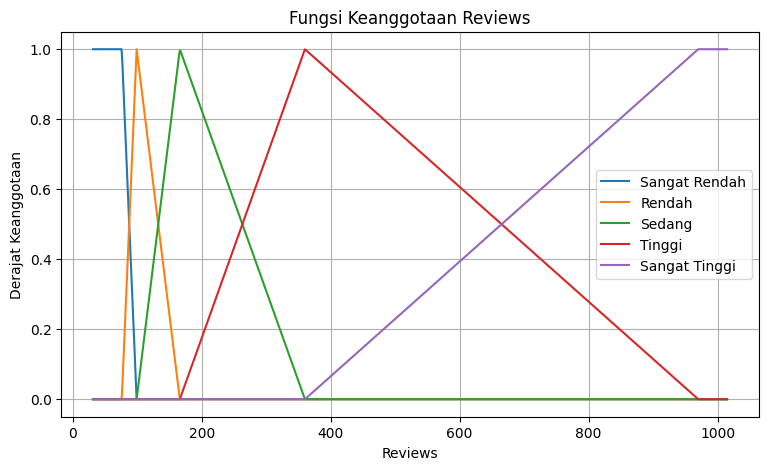

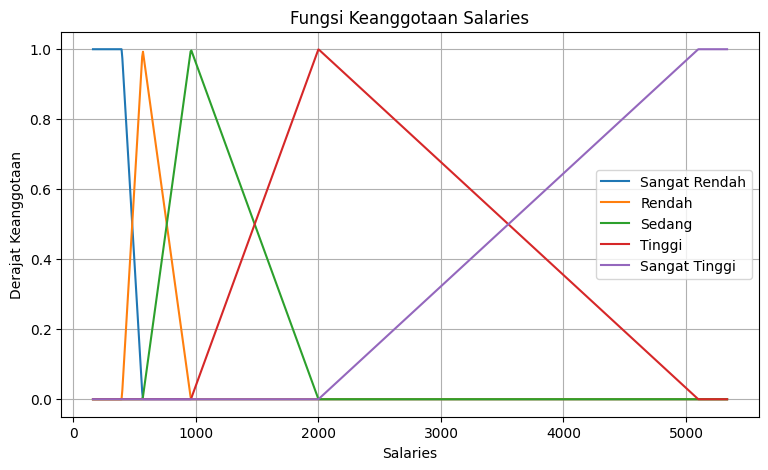

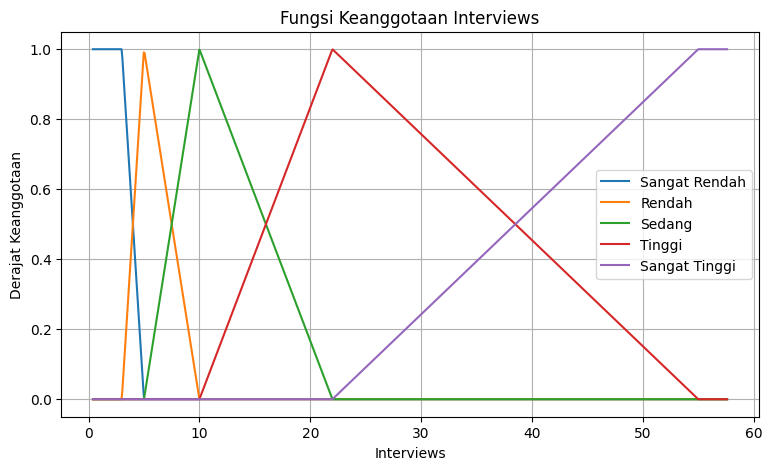

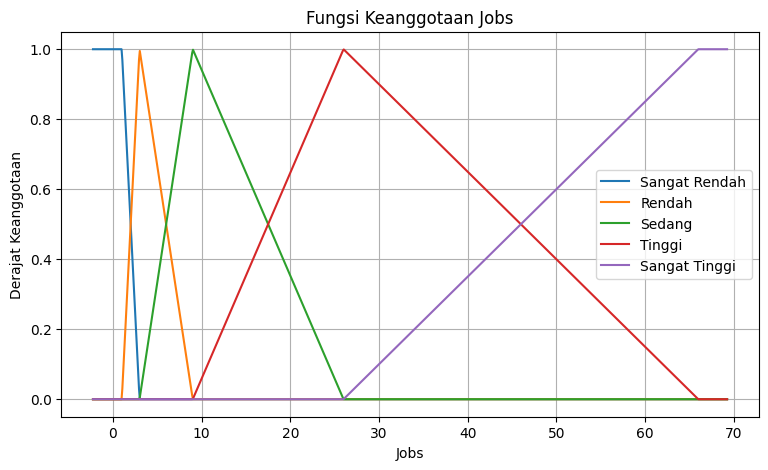

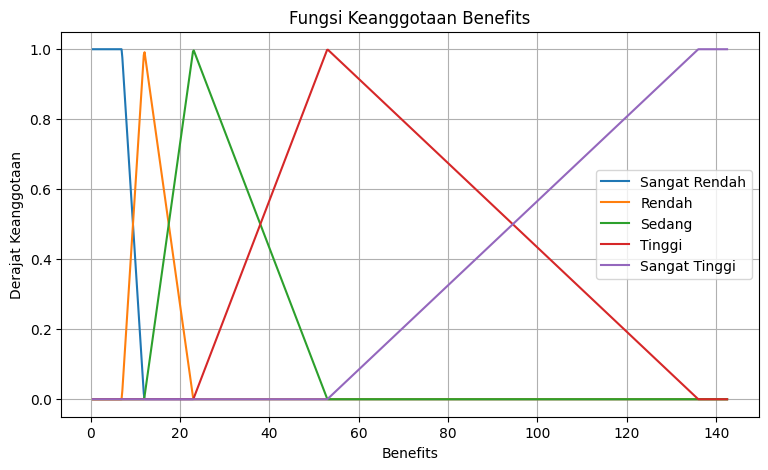

In [19]:
for nama_variabel in input_cols:
    plot_fungsi_keanggotaan(nama_variabel, input_params[nama_variabel])

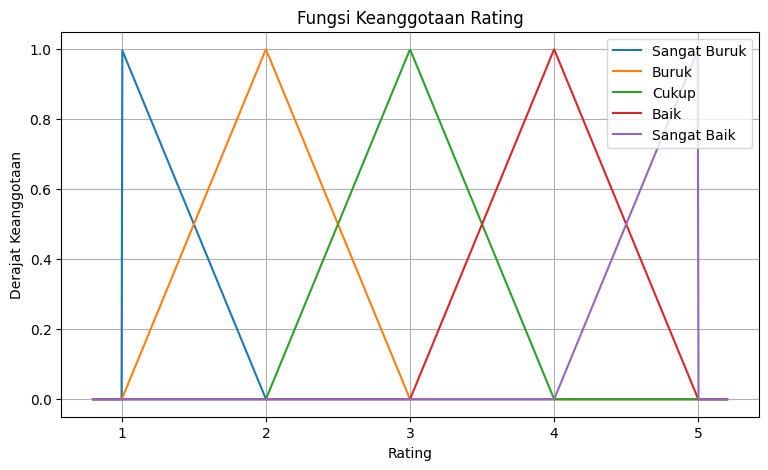

In [20]:
plot_fungsi_keanggotaan('Rating', rating_params, x_min=1, x_max=5)

## 9. Rule Base

Rule base menggunakan operator AND dengan nilai minimum. Jumlah rule lebih dari 15 dan seluruh kategori output digunakan minimal satu kali.

In [21]:
rules = []

for var in input_cols:
    rules.append(({var: 'sangat_rendah'}, 'cukup'))
    rules.append(({var: 'rendah'}, 'baik'))
    rules.append(({var: 'sedang'}, 'baik'))
    rules.append(({var: 'tinggi'}, 'baik'))
    rules.append(({var: 'sangat_tinggi'}, 'baik'))

rules.extend([
    ({'Reviews': 'sangat_tinggi', 'Salaries': 'sangat_tinggi', 'Benefits': 'sangat_tinggi'}, 'sangat_baik'),
    ({'Reviews': 'sangat_tinggi', 'Benefits': 'sangat_tinggi'}, 'sangat_baik'),
    ({'Reviews': 'sangat_tinggi', 'Jobs': 'sangat_tinggi', 'Benefits': 'sangat_tinggi'}, 'sangat_baik'),
    ({'Salaries': 'sangat_tinggi', 'Interviews': 'sangat_tinggi', 'Jobs': 'sangat_tinggi'}, 'sangat_baik'),
    ({'Reviews': 'sangat_rendah', 'Salaries': 'sangat_rendah', 'Benefits': 'sangat_rendah', 'Interviews': 'sangat_rendah', 'Jobs': 'sangat_rendah'}, 'sangat_buruk'),
    ({'Reviews': 'sangat_rendah', 'Salaries': 'sangat_rendah', 'Benefits': 'sangat_rendah'}, 'buruk'),
    ({'Reviews': 'sangat_rendah', 'Jobs': 'sangat_rendah', 'Benefits': 'sangat_rendah'}, 'buruk'),
    ({'Salaries': 'sangat_rendah', 'Interviews': 'sangat_rendah', 'Jobs': 'sangat_rendah'}, 'buruk')
])

rule_table = pd.DataFrame([
    {'No': i + 1, 'IF': kondisi, 'THEN': output}
    for i, (kondisi, output) in enumerate(rules)
])

rule_table

,No,IF,THEN
0,1,{'Reviews': 'sangat_rendah'},cukup
1,2,{'Reviews': 'rendah'},baik
2,3,{'Reviews': 'sedang'},baik
3,4,{'Reviews': 'tinggi'},baik
4,5,{'Reviews': 'sangat_tinggi'},baik
5,6,{'Salaries': 'sangat_rendah'},cukup
6,7,{'Salaries': 'rendah'},baik
7,8,{'Salaries': 'sedang'},baik
8,9,{'Salaries': 'tinggi'},baik
9,10,{'Salaries': 'sangat_tinggi'},baik


In [22]:
rule_table['THEN'].value_counts()

,count
THEN,
baik,20
cukup,5
sangat_baik,4
buruk,3
sangat_buruk,1


## 10. Inferensi Mamdani

Mamdani menggunakan firing strength `alpha` dari minimum derajat keanggotaan, clipping pada fungsi keanggotaan output, agregasi maksimum, lalu defuzzifikasi centroid.

In [23]:
def agregasi_mamdani(row):
    fuzzy = fuzzifikasi(row)
    agregasi = np.zeros_like(rating_domain)

    for kondisi, output in rules:
        alpha = min(fuzzy[var][label] for var, label in kondisi.items())
        implikasi = np.minimum(alpha, rating_mf[output])
        agregasi = np.maximum(agregasi, implikasi)

    return agregasi


def defuzzifikasi_centroid(domain, agregasi):
    if agregasi.sum() == 0:
        return 3.8
    return np.sum(domain * agregasi) / np.sum(agregasi)


def inferensi_mamdani(row):
    agregasi = agregasi_mamdani(row)
    return defuzzifikasi_centroid(rating_domain, agregasi)

## 11. Inferensi Sugeno

Sugeno menggunakan firing strength yang sama, tetapi konsekuen rule berupa konstanta rating.

In [24]:
sugeno_const = {
    'sangat_buruk': 1,
    'buruk': 2,
    'cukup': 3,
    'baik': 4,
    'sangat_baik': 5
}


def inferensi_sugeno(row):
    fuzzy = fuzzifikasi(row)
    pembilang = 0.0
    penyebut = 0.0

    for kondisi, output in rules:
        alpha = min(fuzzy[var][label] for var, label in kondisi.items())
        pembilang += alpha * sugeno_const[output]
        penyebut += alpha

    if penyebut == 0:
        return 3.8

    return pembilang / penyebut

## 12. Prediksi

In [25]:
y_pred_mamdani = X.apply(inferensi_mamdani, axis=1)
y_pred_sugeno = X.apply(inferensi_sugeno, axis=1)

hasil = df_model.copy()
hasil['Prediksi_Mamdani'] = y_pred_mamdani
hasil['Prediksi_Sugeno'] = y_pred_sugeno
hasil['Error_Mamdani'] = abs(hasil['Rating'] - hasil['Prediksi_Mamdani'])
hasil['Error_Sugeno'] = abs(hasil['Rating'] - hasil['Prediksi_Sugeno'])

hasil.head()

,Reviews,Salaries,Interviews,Jobs,Benefits,Rating,Prediksi_Mamdani,Prediksi_Sugeno,Error_Mamdani,Error_Sugeno
0,67000.0,737100.0,5600.0,278.0,11300.0,3.8,4.17,4.444444,0.37,0.644444
1,42900.0,513800.0,3900.0,4100.0,7000.0,4.1,4.17,4.444444,0.07,0.344444
2,38600.0,497300.0,3300.0,480.0,5800.0,3.9,4.17,4.444444,0.27,0.544444
3,35600.0,371300.0,3300.0,340.0,4900.0,3.8,4.17,4.444444,0.37,0.644444
4,31000.0,136400.0,1700.0,216.0,3700.0,4.0,4.17,4.444444,0.17,0.444444


In [26]:
df_result = hasil.rename(columns={
    'Prediksi_Mamdani': 'Mamdani_Prediction',
    'Prediksi_Sugeno': 'Sugeno_Prediction'
})

df_result[['Rating', 'Mamdani_Prediction', 'Sugeno_Prediction']].head()

,Rating,Mamdani_Prediction,Sugeno_Prediction
0,3.8,4.17,4.444444
1,4.1,4.17,4.444444
2,3.9,4.17,4.444444
3,3.8,4.17,4.444444
4,4.0,4.17,4.444444


## 13. Evaluasi

Karena output `Rating` berbentuk nilai kontinu, evaluasi menggunakan MAE dan MSE.

In [27]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


hasil_evaluasi = pd.DataFrame({
    'Metode': ['Mamdani', 'Sugeno'],
    'MAE': [mae(y, y_pred_mamdani), mae(y, y_pred_sugeno)],
    'MSE': [mse(y, y_pred_mamdani), mse(y, y_pred_sugeno)]
})

evaluasi = hasil_evaluasi.copy()
hasil_evaluasi

,Metode,MAE,MSE
0,Mamdani,0.404031,0.272787
1,Sugeno,0.382993,0.249099


In [28]:
hasil[['Rating', 'Prediksi_Mamdani', 'Prediksi_Sugeno', 'Error_Mamdani', 'Error_Sugeno']].head(20)

,Rating,Prediksi_Mamdani,Prediksi_Sugeno,Error_Mamdani,Error_Sugeno
0,3.8,4.17,4.444444,0.37,0.644444
1,4.1,4.17,4.444444,0.07,0.344444
2,3.9,4.17,4.444444,0.27,0.544444
3,3.8,4.17,4.444444,0.37,0.644444
4,4.0,4.17,4.444444,0.17,0.444444
5,3.9,4.17,4.444444,0.27,0.544444
6,3.9,4.17,4.444444,0.27,0.544444
7,3.8,4.17,4.444444,0.37,0.644444
8,3.7,4.17,4.444444,0.47,0.744444
9,3.7,4.17,4.444444,0.47,0.744444


## 14. Visualisasi Fuzzifikasi Sampel

Sampel yang dipakai untuk visualisasi dipilih dari data yang paling dekat dengan median agar grafik tidak rusak oleh outlier ekstrem.

In [29]:
def pilih_index_representatif(X):
    standar = X.std().replace(0, 1)
    jarak = ((X - X.median()).abs() / standar).sum(axis=1)
    return int(jarak.idxmin())


sample_index = pilih_index_representatif(X)
sample_index, X.iloc[sample_index], y.iloc[sample_index]

(2758,
 Reviews       181.0
 Salaries      890.0
 Interviews      9.0
 Jobs            9.0
 Benefits       24.0
 Name: 2758, dtype: float64,
 np.float64(3.7))

In [30]:
def plot_fuzzifikasi_sampel(index_data):
    sampel = X.iloc[index_data]

    for nama_variabel in input_cols:
        params = input_params[nama_variabel]

        semua_batas = []
        for p in params.values():
            semua_batas.extend(p[1:])

        x_min = min(semua_batas)
        x_max = max(semua_batas)
        rentang = x_max - x_min
        x = np.linspace(x_min - 0.05 * rentang, x_max + 0.05 * rentang, 800)

        nilai_crisp = sampel[nama_variabel]

        plt.figure(figsize=(9, 5))

        for label, parameter in params.items():
            y_plot = [hitung_mf(nilai, parameter) for nilai in x]
            derajat = hitung_mf(nilai_crisp, parameter)
            plt.plot(x, y_plot, label=f"{label.replace('_', ' ').title()} = {derajat:.3f}")

            if derajat > 0:
                plt.scatter([nilai_crisp], [derajat], s=60)

        plt.axvline(nilai_crisp, linestyle='--', label=f'Nilai crisp = {nilai_crisp:.0f}')
        plt.title(f'Fuzzifikasi {nama_variabel} Data ke-{index_data}')
        plt.xlabel(nama_variabel)
        plt.ylabel('Derajat Keanggotaan')
        plt.ylim(-0.05, 1.05)
        plt.legend(loc='best')
        plt.show()

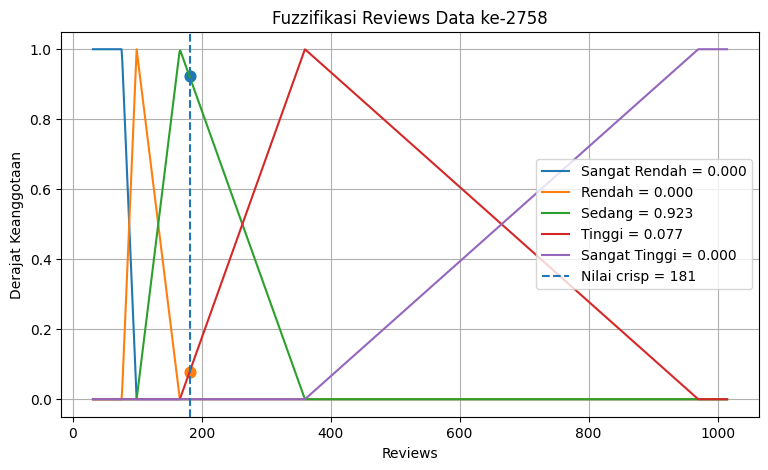

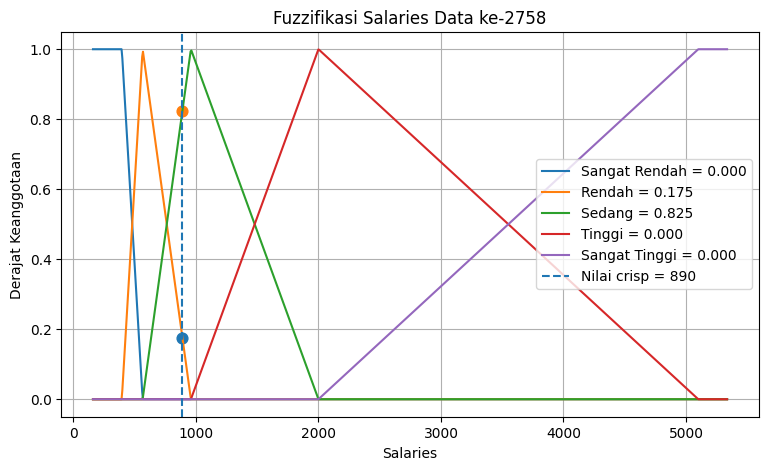

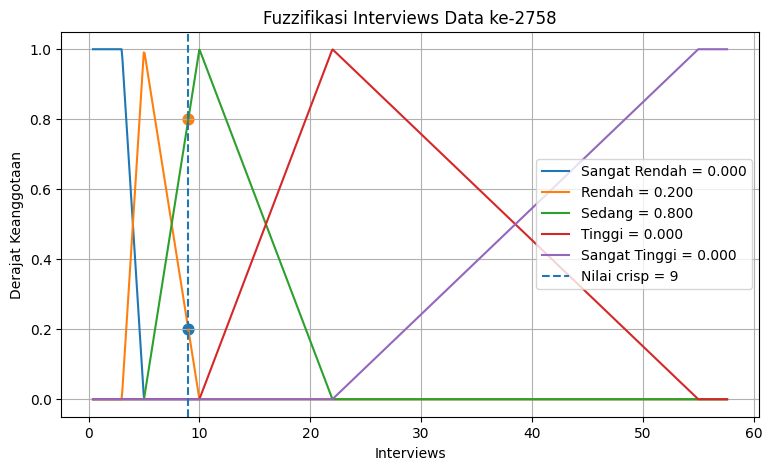

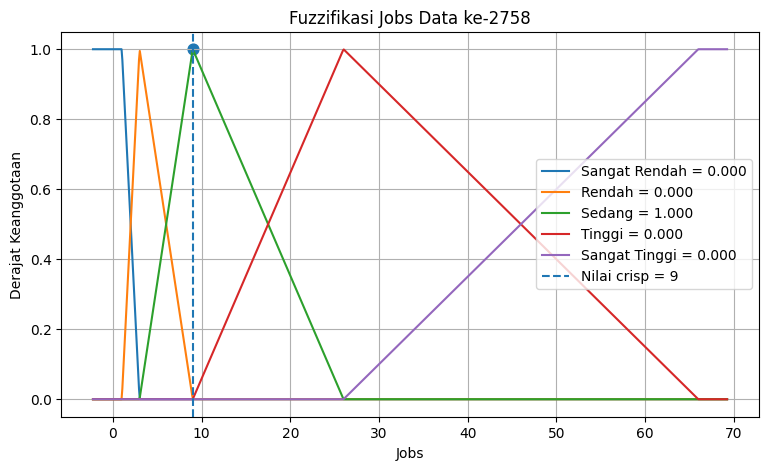

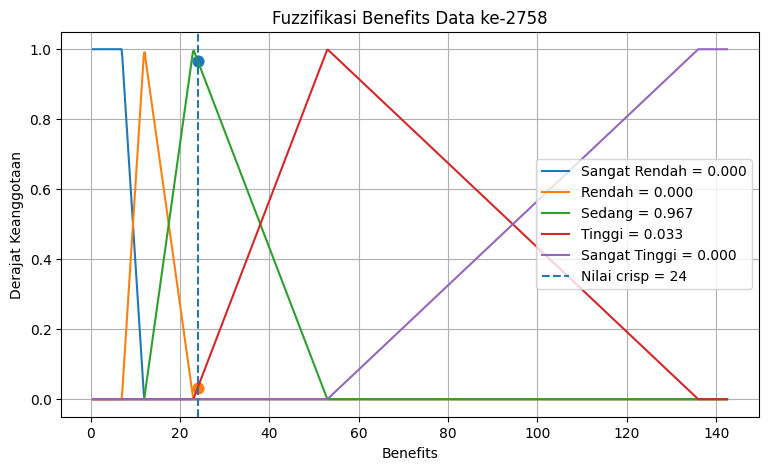

In [31]:
plot_fuzzifikasi_sampel(sample_index)

## 15. Visualisasi Inferensi dan Defuzzifikasi Mamdani

In [32]:
def plot_output_mamdani(index_data):
    row = X.iloc[index_data]
    agregasi = agregasi_mamdani(row)
    hasil_centroid = defuzzifikasi_centroid(rating_domain, agregasi)

    plt.figure(figsize=(9, 5))

    for label, mf in rating_mf.items():
        plt.plot(rating_domain, mf, linestyle='--', label=label.replace('_', ' ').title())

    plt.fill_between(rating_domain, agregasi, alpha=0.35, label='Agregasi Mamdani')
    plt.axvline(hasil_centroid, linestyle='-', label=f'Centroid = {hasil_centroid:.3f}')

    plt.title(f'Inferensi dan Defuzzifikasi Mamdani Data ke-{index_data}')
    plt.xlabel('Rating')
    plt.ylabel('Derajat Keanggotaan')
    plt.ylim(-0.05, 1.05)
    plt.legend(loc='best')
    plt.show()

    return hasil_centroid

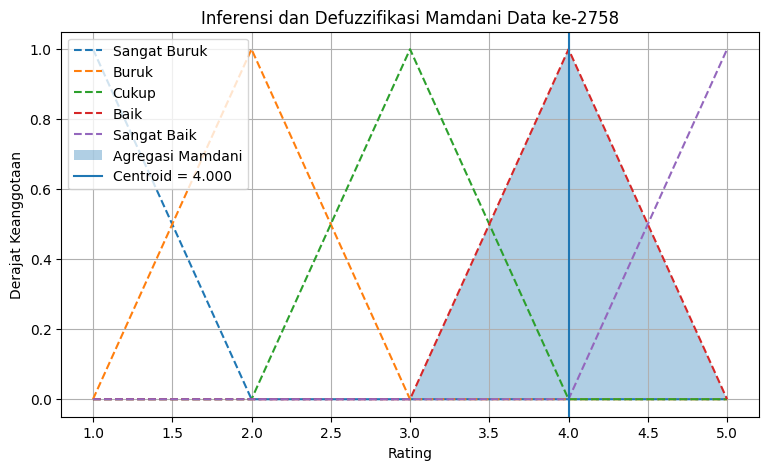

np.float64(4.0)

In [33]:
plot_output_mamdani(sample_index)

## 16. Visualisasi Hasil Prediksi dan Error

In [34]:
def plot_perbandingan_prediksi(jumlah_data=50):
    data_plot = hasil.head(jumlah_data).copy()
    x = np.arange(len(data_plot))

    plt.figure(figsize=(12, 5))

    plt.plot(x, data_plot['Rating'], marker='o', label='Rating Aktual')
    plt.plot(x, data_plot['Prediksi_Mamdani'], marker='o', label='Prediksi Mamdani')
    plt.plot(x, data_plot['Prediksi_Sugeno'], marker='o', label='Prediksi Sugeno')

    plt.title(f'Perbandingan Rating Aktual, Mamdani, dan Sugeno ({jumlah_data} Data Pertama)')
    plt.xlabel('Index Data')
    plt.ylabel('Rating')
    plt.ylim(1, 5)
    plt.legend(loc='best')
    plt.show()

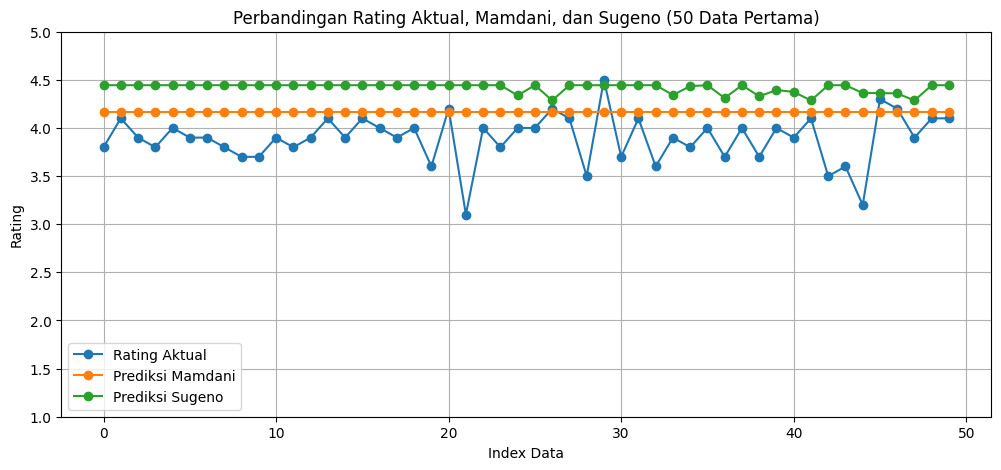

In [35]:
plot_perbandingan_prediksi(50)

In [36]:
def plot_error_mamdani_sugeno():
    metode = hasil_evaluasi['Metode']
    mae_values = hasil_evaluasi['MAE']
    mse_values = hasil_evaluasi['MSE']

    x = np.arange(len(metode))
    width = 0.35

    plt.figure(figsize=(8, 5))
    plt.bar(x - width / 2, mae_values, width, label='MAE')
    plt.bar(x + width / 2, mse_values, width, label='MSE')

    plt.xticks(x, metode)
    plt.title('Evaluasi Error Mamdani dan Sugeno')
    plt.xlabel('Metode')
    plt.ylabel('Nilai Error')
    plt.legend(loc='best')
    plt.show()

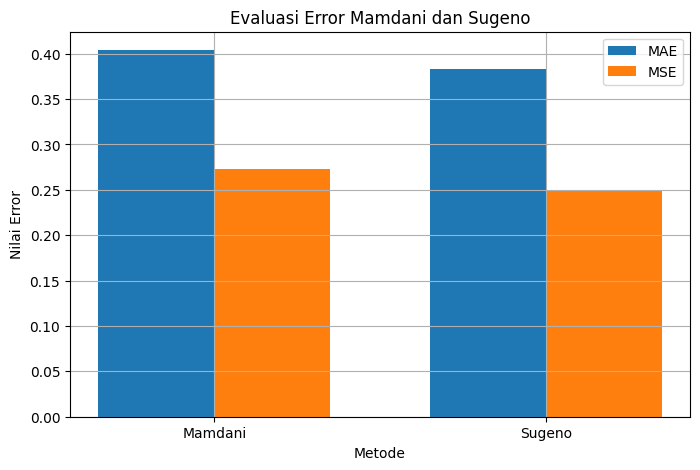

In [37]:
plot_error_mamdani_sugeno()

## 17. Validasi Distribusi Label Dominan Input

Validasi ini digunakan untuk memastikan batas linguistik tidak membuat hampir seluruh data jatuh pada satu kategori saja.

In [38]:
dominant_labels = {}

for col in input_cols:
    labels = []
    for value in X[col]:
        membership = nilai_keanggotaan_input(value, input_params[col])
        labels.append(max(membership, key=membership.get))
    dominant_labels[col] = pd.Series(labels).value_counts()

dominant_table = pd.DataFrame(dominant_labels).fillna(0).astype(int)
dominant_table

,Reviews,Salaries,Interviews,Jobs,Benefits
rendah,1297,1281,1101,1223,1383
sangat_rendah,1081,1053,1278,1232,966
sangat_tinggi,833,865,887,845,859
sedang,1542,1516,1640,1459,1593
tinggi,1114,1152,961,1108,1066


## 18. Validasi Ketentuan Tugas

In [39]:
validasi_ketentuan = pd.DataFrame({
    'ketentuan': [
        'Dataset minimal 5000 row setelah preprocessing',
        'Minimal 5 variabel input',
        'Minimal 1 output',
        'Rule base minimal 15 rule',
        'Implementasi Mamdani',
        'Implementasi Sugeno',
        'Fuzzifikasi',
        'Inferensi',
        'Defuzzifikasi',
        'Tanpa library fuzzy'
    ],
    'hasil': [
        len(df_model) >= 5000,
        len(input_cols) >= 5,
        output_col in df_model.columns,
        len(rules) >= 15,
        callable(inferensi_mamdani),
        callable(inferensi_sugeno),
        callable(fuzzifikasi),
        True,
        True,
        True
    ]
})

validasi_ketentuan

,ketentuan,hasil
0,Dataset minimal 5000 row setelah preprocessing,True
1,Minimal 5 variabel input,True
2,Minimal 1 output,True
3,Rule base minimal 15 rule,True
4,Implementasi Mamdani,True
5,Implementasi Sugeno,True
6,Fuzzifikasi,True
7,Inferensi,True
8,Defuzzifikasi,True
9,Tanpa library fuzzy,True


## 19. Analisis Mamdani vs Sugeno

Mamdani menghasilkan output dengan cara membentuk fuzzy set pada konsekuen rule, melakukan clipping berdasarkan firing strength, menggabungkan seluruh output rule menggunakan maksimum, kemudian mengubah hasil fuzzy menjadi nilai crisp dengan centroid.

Sugeno menghasilkan output dengan cara memberi konstanta pada setiap konsekuen rule. Nilai akhir dihitung sebagai rata-rata berbobot dari konstanta tersebut menggunakan firing strength setiap rule.

Berdasarkan hasil evaluasi, metode dengan MAE dan MSE lebih kecil adalah metode yang lebih dekat dengan rating aktual.

Kelebihan Mamdani adalah lebih mudah dijelaskan secara linguistik karena konsekuennya masih berupa fuzzy set sebelum defuzzifikasi. Kekurangannya adalah proses agregasi dan centroid lebih panjang. Kelebihan Sugeno adalah perhitungannya lebih sederhana dan efisien karena konsekuennya berupa konstanta. Kekurangannya adalah bentuk output kurang ekspresif dibanding Mamdani karena tidak membentuk fuzzy set output secara eksplisit.

## 20. Simpan Hasil

In [40]:
hasil.to_csv('hasil_prediksi_fuzzy_final_fix.csv', index=False)
hasil_evaluasi.to_csv('evaluasi_fuzzy_final_fix.csv', index=False)

Path('hasil_prediksi_fuzzy_final_fix.csv').exists(), Path('evaluasi_fuzzy_final_fix.csv').exists()

(True, True)